In [21]:
## **for dataset creation **
import pandas as pd
import numpy as np
from IPython.display import FileLink

# Random data reproducibility
np.random.seed(42)

# Number of records
n = 2000

# 1. Order ID
order_id = [f"O{5001+i}" for i in range(n)]

# 2. Order Date
order_date = pd.to_datetime("2026-01-01") + pd.to_timedelta(
    np.random.randint(0, 273, n),
    unit="D"
)

# 3. Warehouse
warehouse = np.random.choice(
    [
        "WH-Chennai",
        "WH-Bangalore",
        "WH-Hyderabad",
        "WH-Mumbai",
        "WH-Pune"
    ],
    n
)

# 4. Region
region_map = {
    "WH-Chennai": "South",
    "WH-Bangalore": "South",
    "WH-Hyderabad": "South",
    "WH-Mumbai": "West",
    "WH-Pune": "West"
}

region = [region_map[w] for w in warehouse]

# 5. Carrier
carrier = np.random.choice(
    ["Carrier A", "Carrier B", "Carrier C", "Carrier D"],
    n
)

# 6. Promised Date
promised_date = order_date + pd.to_timedelta(
    np.random.randint(3, 9, n),
    unit="D"
)

# 7. Status
status = np.random.choice(
    ["Delivered", "Cancelled"],
    n,
    p=[0.93, 0.07]
)

# 8. Delivery delay
delay = np.random.choice(
    [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7],
    n,
    p=[0.02, 0.08, 0.48, 0.13, 0.09, 0.07, 0.05, 0.04, 0.025, 0.015]
)

# 9. Delivered Date
delivered_date = promised_date + pd.to_timedelta(
    delay,
    unit="D"
)

# Cancelled orders have no delivered date
delivered_date = delivered_date.where(
    status == "Delivered",
    pd.NaT
)

# 10. Shipping Cost
shipping_cost = np.round(
    np.random.uniform(250, 1500, n),
    2
)

# 11. Order Quantity
order_quantity = np.random.randint(1, 21, n)

# 12. Weight
weight_kg = np.round(
    np.random.uniform(20, 1000, n),
    2
)

# Create DataFrame - EXACTLY 12 COLUMNS
df = pd.DataFrame({
    "order_id": order_id,
    "order_date": order_date,
    "warehouse": warehouse,
    "region": region,
    "promised_date": promised_date,
    "delivered_date": delivered_date,
    "carrier": carrier,
    "shipping_cost": shipping_cost,
    "status": status,
    "order_quantity": order_quantity,
    "weight_kg": weight_kg,
    "delay": delay
})

# Save as CSV
df.to_csv("supply_chain_orders.csv", index=False)

# Verify
print("Dataset created successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

# Download link
FileLink("supply_chain_orders.csv")

Dataset created successfully!
Rows: 2000
Columns: 12

Column Names:
['order_id', 'order_date', 'warehouse', 'region', 'promised_date', 'delivered_date', 'carrier', 'shipping_cost', 'status', 'order_quantity', 'weight_kg', 'delay']


C:\Users\user\supply_chain_orders.csv

In [22]:
import pandas as pd
import numpy as np

# Load CSV file
df = pd.read_csv("supply_chain_orders.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 2000
Columns: 12


In [23]:
df.head()

,order_id,order_date,warehouse,region,promised_date,delivered_date,carrier,shipping_cost,status,order_quantity,weight_kg,delay
0,O5001,2026-04-13,WH-Mumbai,West,2026-04-17,2026-04-17,Carrier A,566.07,Delivered,13,246.52,0
1,O5002,2026-09-28,WH-Pune,West,2026-10-03,2026-10-03,Carrier C,896.75,Delivered,17,891.21,0
2,O5003,2026-04-17,WH-Hyderabad,South,2026-04-21,NaN,Carrier A,268.70,Cancelled,17,73.85,0
3,O5004,2026-03-13,WH-Chennai,South,2026-03-18,2026-03-19,Carrier C,580.68,Delivered,4,193.08,1
4,O5005,2026-07-08,WH-Mumbai,West,2026-07-16,2026-07-18,Carrier C,892.54,Delivered,14,557.75,2


In [24]:
print(df.columns.tolist())

['order_id', 'order_date', 'warehouse', 'region', 'promised_date', 'delivered_date', 'carrier', 'shipping_cost', 'status', 'order_quantity', 'weight_kg', 'delay']


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        2000 non-null   str    
 1   order_date      2000 non-null   str    
 2   warehouse       2000 non-null   str    
 3   region          2000 non-null   str    
 4   promised_date   2000 non-null   str    
 5   delivered_date  1856 non-null   str    
 6   carrier         2000 non-null   str    
 7   shipping_cost   2000 non-null   float64
 8   status          2000 non-null   str    
 9   order_quantity  2000 non-null   int64  
 10  weight_kg       2000 non-null   float64
 11  delay           2000 non-null   int64  
dtypes: float64(2), int64(2), str(8)
memory usage: 318.4 KB


In [26]:
df.isnull().sum()

order_id            0
order_date          0
warehouse           0
region              0
promised_date       0
delivered_date    144
carrier             0
shipping_cost       0
status              0
order_quantity      0
weight_kg           0
delay               0
dtype: int64

In [27]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Order IDs:", df["order_id"].duplicated().sum())

Duplicate rows: 0
Duplicate Order IDs: 0


In [28]:
print("===== DATA CLEANING CHECK =====")

# 1. Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# 2. Duplicate Order IDs
print("Duplicate Order IDs:", df["order_id"].duplicated().sum())

# 3. Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# 4. Negative shipping cost
print("\nNegative Shipping Cost:",
      (df["shipping_cost"] < 0).sum())

# 5. Invalid quantity
print("Invalid Quantity:",
      (df["order_quantity"] <= 0).sum())

# 6. Invalid weight
print("Invalid Weight:",
      (df["weight_kg"] <= 0).sum())

# 7. Invalid dates
print("\nInvalid Order Dates:",
      df["order_date"].isnull().sum())

print("Invalid Promised Dates:",
      df["promised_date"].isnull().sum())

print("Invalid Delivered Dates:",
      df["delivered_date"].isnull().sum())

print("\n===== CLEANING CHECK COMPLETED =====")

===== DATA CLEANING CHECK =====
Duplicate rows: 0
Duplicate Order IDs: 0

Missing Values:
order_id            0
order_date          0
warehouse           0
region              0
promised_date       0
delivered_date    144
carrier             0
shipping_cost       0
status              0
order_quantity      0
weight_kg           0
delay               0
dtype: int64

Negative Shipping Cost: 0
Invalid Quantity: 0
Invalid Weight: 0

Invalid Order Dates: 0
Invalid Promised Dates: 0
Invalid Delivered Dates: 144

===== CLEANING CHECK COMPLETED =====


In [29]:
print(df["status"].value_counts())

status
Delivered    1856
Cancelled     144
Name: count, dtype: int64


In [30]:
# Convert date columns from string to datetime
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df["promised_date"] = pd.to_datetime(df["promised_date"], errors="coerce")
df["delivered_date"] = pd.to_datetime(df["delivered_date"], errors="coerce")

# Calculate delivery days
df["delivery_days"] = (
    df["delivered_date"] - df["order_date"]
).dt.days

# Display result
df[[
    "order_id",
    "status",
    "order_date",
    "delivered_date",
    "delivery_days"
]].head(10)

,order_id,status,order_date,delivered_date,delivery_days
0,O5001,Delivered,2026-04-13,2026-04-17,4.0
1,O5002,Delivered,2026-09-28,2026-10-03,5.0
2,O5003,Cancelled,2026-04-17,NaT,NaN
3,O5004,Delivered,2026-03-13,2026-03-19,6.0
4,O5005,Delivered,2026-07-08,2026-07-18,10.0
5,O5006,Delivered,2026-01-21,2026-01-26,5.0
6,O5007,Delivered,2026-04-13,2026-04-26,13.0
7,O5008,Cancelled,2026-05-02,NaT,NaN
8,O5009,Cancelled,2026-08-03,NaT,NaN
9,O5010,Delivered,2026-03-29,2026-04-06,8.0


In [31]:
# Make sure date columns are datetime
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df["promised_date"] = pd.to_datetime(df["promised_date"], errors="coerce")
df["delivered_date"] = pd.to_datetime(df["delivered_date"], errors="coerce")

In [32]:
df["delivery_days"] = (
    df["delivered_date"] - df["order_date"]
).dt.days

df[["order_id", "status", "order_date", "delivered_date", "delivery_days"]].head(10)

,order_id,status,order_date,delivered_date,delivery_days
0,O5001,Delivered,2026-04-13,2026-04-17,4.0
1,O5002,Delivered,2026-09-28,2026-10-03,5.0
2,O5003,Cancelled,2026-04-17,NaT,NaN
3,O5004,Delivered,2026-03-13,2026-03-19,6.0
4,O5005,Delivered,2026-07-08,2026-07-18,10.0
5,O5006,Delivered,2026-01-21,2026-01-26,5.0
6,O5007,Delivered,2026-04-13,2026-04-26,13.0
7,O5008,Cancelled,2026-05-02,NaT,NaN
8,O5009,Cancelled,2026-08-03,NaT,NaN
9,O5010,Delivered,2026-03-29,2026-04-06,8.0


In [33]:
# Calculate delay days
df["delay_days"] = (
    df["delivered_date"] - df["promised_date"]
).dt.days

In [34]:
# On-time delivery flag
df["on_time_flag"] = np.where(
    (df["status"] == "Delivered") & (df["delay_days"] <= 0),
    1,
    0
)

In [35]:
# Classify orders
def classify_order(row):
    if row["status"] == "Cancelled":
        return "Cancelled"
    elif row["delay_days"] > 0:
        return "Delayed"
    else:
        return "On Time"

df["delivery_class"] = df.apply(classify_order, axis=1)


In [36]:
# Check result
print("Delivery Classification:")
print(df["delivery_class"].value_counts())

print("\nSample Data:")
display(df[
    [
        "order_id",
        "status",
        "promised_date",
        "delivered_date",
        "delay_days",
        "on_time_flag",
        "delivery_class"
    ]
].head(10))

Delivery Classification:
delivery_class
On Time      1121
Delayed       735
Cancelled     144
Name: count, dtype: int64

Sample Data:


,order_id,status,promised_date,delivered_date,delay_days,on_time_flag,delivery_class
0,O5001,Delivered,2026-04-17,2026-04-17,0.0,1,On Time
1,O5002,Delivered,2026-10-03,2026-10-03,0.0,1,On Time
2,O5003,Cancelled,2026-04-21,NaT,NaN,0,Cancelled
3,O5004,Delivered,2026-03-18,2026-03-19,1.0,0,Delayed
4,O5005,Delivered,2026-07-16,2026-07-18,2.0,0,Delayed
5,O5006,Delivered,2026-01-28,2026-01-26,-2.0,1,On Time
6,O5007,Delivered,2026-04-21,2026-04-26,5.0,0,Delayed
7,O5008,Cancelled,2026-05-08,NaT,NaN,0,Cancelled
8,O5009,Cancelled,2026-08-11,NaT,NaN,0,Cancelled
9,O5010,Delivered,2026-04-06,2026-04-06,0.0,1,On Time


In [38]:
# Total delivered
total_delivered = len(delivered_orders)
print("Delivered Orders:", total_delivered)


Delivered Orders: 1856


In [40]:
# Delivered orders only
delivered_orders = df[df["status"] == "Delivered"].copy()
print("Delivered Orders:", total_delivered)

Delivered Orders: 1856


In [41]:
# Total orders
total_orders = len(df)
print("Total Orders:", total_orders)

Total Orders: 2000


In [42]:
# Total cancelled
total_cancelled = len(df[df["status"] == "Cancelled"])
print("Cancelled Orders:", total_cancelled)

Cancelled Orders: 144


In [43]:
# On-time delivered orders
on_time_orders = len(
    delivered_orders[delivered_orders["delay_days"] <= 0]
)
print("On-Time Orders:", on_time_orders)

On-Time Orders: 1121


In [44]:
# On-time delivery percentage
on_time_percentage = (
    on_time_orders / total_delivered
) * 100
print("On-Time Delivery %:", round(on_time_percentage, 2), "%")

On-Time Delivery %: 60.4 %


In [45]:
# Average delay - delayed orders only
delayed_orders = delivered_orders[
    delivered_orders["delay_days"] > 0
]
average_delay = delayed_orders["delay_days"].mean()
print("Average Delay:", round(average_delay, 2), "days")

Average Delay: 2.75 days


In [46]:
# Average shipping cost
average_shipping_cost = df["shipping_cost"].mean()
print("Average Shipping Cost:", round(average_shipping_cost, 2))

Average Shipping Cost: 881.89


In [47]:
###**** kpi above ***
print("===== SUPPLY CHAIN KPIs =====")
print("Total Orders:", total_orders)
print("Delivered Orders:", total_delivered)
print("Cancelled Orders:", total_cancelled)
print("On-Time Orders:", on_time_orders)
print("On-Time Delivery %:", round(on_time_percentage, 2), "%")
print("Average Delay:", round(average_delay, 2), "days")
print("Average Shipping Cost:", round(average_shipping_cost, 2))

===== SUPPLY CHAIN KPIs =====
Total Orders: 2000
Delivered Orders: 1856
Cancelled Orders: 144
On-Time Orders: 1121
On-Time Delivery %: 60.4 %
Average Delay: 2.75 days
Average Shipping Cost: 881.89


In [48]:
warehouse_analysis = df.groupby("warehouse").agg(
    total_orders=("order_id", "count"),
    delayed_orders=("delivery_class", lambda x: (x == "Delayed").sum()),
    on_time_orders=("delivery_class", lambda x: (x == "On Time").sum()),
    cancelled_orders=("delivery_class", lambda x: (x == "Cancelled").sum()),
    average_delay=("delay_days", "mean"),
    total_shipping_cost=("shipping_cost", "sum")
).reset_index()

warehouse_analysis["delay_rate"] = (
    warehouse_analysis["delayed_orders"]
    / warehouse_analysis["total_orders"] * 100
).round(2)

warehouse_analysis["on_time_percentage"] = (
    warehouse_analysis["on_time_orders"]
    / warehouse_analysis["total_orders"] * 100
).round(2)

print(warehouse_analysis)

      warehouse  total_orders  delayed_orders  on_time_orders  \
0  WH-Bangalore           363             128             206   
1    WH-Chennai           408             147             228   
2  WH-Hyderabad           422             159             232   
3     WH-Mumbai           402             153             222   
4       WH-Pune           405             148             233   

   cancelled_orders  average_delay  total_shipping_cost  delay_rate  \
0                29       0.994012            318250.59       35.26   
1                33       0.941333            364395.31       36.03   
2                31       1.015345            371649.93       37.68   
3                27       0.989333            356785.34       38.06   
4                24       0.905512            352705.00       36.54   

   on_time_percentage  
0               56.75  
1               55.88  
2               54.98  
3               55.22  
4               57.53  


In [49]:
warehouse_analysis.sort_values(
    "delay_rate",
    ascending=False
)

,warehouse,total_orders,delayed_orders,on_time_orders,cancelled_orders,average_delay,total_shipping_cost,delay_rate,on_time_percentage
3,WH-Mumbai,402,153,222,27,0.989333,356785.34,38.06,55.22
2,WH-Hyderabad,422,159,232,31,1.015345,371649.93,37.68,54.98
4,WH-Pune,405,148,233,24,0.905512,352705.00,36.54,57.53
1,WH-Chennai,408,147,228,33,0.941333,364395.31,36.03,55.88
0,WH-Bangalore,363,128,206,29,0.994012,318250.59,35.26,56.75


In [50]:
carrier_analysis = df.groupby("carrier").agg(
    total_orders=("order_id", "count"),
    delivered_orders=("status", lambda x: (x == "Delivered").sum()),
    cancelled_orders=("status", lambda x: (x == "Cancelled").sum()),
    delayed_orders=("delivery_class", lambda x: (x == "Delayed").sum()),
    avg_shipping_cost=("shipping_cost", "mean"),
    avg_delay_days=("delay_days", "mean")
).reset_index()

carrier_analysis["delay_rate"] = (
    carrier_analysis["delayed_orders"]
    / carrier_analysis["total_orders"]
) * 100

carrier_analysis = carrier_analysis.round(2)

carrier_analysis

,carrier,total_orders,delivered_orders,cancelled_orders,delayed_orders,avg_shipping_cost,avg_delay_days,delay_rate
0,Carrier A,464,434,30,162,863.44,0.88,34.91
1,Carrier B,498,460,38,205,879.65,1.10,41.16
2,Carrier C,516,481,35,178,881.63,0.92,34.50
3,Carrier D,522,481,41,190,900.70,0.97,36.40


In [51]:
region_analysis = df.groupby("region").agg(
    total_orders=("order_id", "count"),
    delivered_orders=("status", lambda x: (x == "Delivered").sum()),
    cancelled_orders=("status", lambda x: (x == "Cancelled").sum()),
    delayed_orders=("delivery_class", lambda x: (x == "Delayed").sum()),
    avg_shipping_cost=("shipping_cost", "mean"),
    avg_delay_days=("delay_days", "mean")
).reset_index()

region_analysis["delay_rate"] = (
    region_analysis["delayed_orders"]
    / region_analysis["total_orders"]
) * 100

region_analysis = region_analysis.round(2)

region_analysis

,region,total_orders,delivered_orders,cancelled_orders,delayed_orders,avg_shipping_cost,avg_delay_days,delay_rate
0,South,1193,1100,93,434,883.73,0.98,36.38
1,West,807,756,51,301,879.17,0.95,37.30


In [52]:
# Create month column  & month analysis
df["month"] = df["order_date"].dt.to_period("M").astype(str)

monthly_analysis = df.groupby("month").agg(
    total_orders=("order_id", "count"),
    delivered_orders=("status", lambda x: (x == "Delivered").sum()),
    cancelled_orders=("status", lambda x: (x == "Cancelled").sum()),
    delayed_orders=("delivery_class", lambda x: (x == "Delayed").sum()),
    avg_shipping_cost=("shipping_cost", "mean")
).reset_index()

monthly_analysis["delay_rate"] = (
    monthly_analysis["delayed_orders"]
    / monthly_analysis["total_orders"]
) * 100

monthly_analysis = monthly_analysis.round(2)

monthly_analysis

,month,total_orders,delivered_orders,cancelled_orders,delayed_orders,avg_shipping_cost,delay_rate
0,2026-01,234,222,12,89,911.57,38.03
1,2026-02,202,196,6,75,865.98,37.13
2,2026-03,198,185,13,77,814.35,38.89
3,2026-04,228,199,29,68,888.84,29.82
4,2026-05,246,230,16,95,869.96,38.62
5,2026-06,240,223,17,106,886.26,44.17
6,2026-07,180,166,14,62,891.04,34.44
7,2026-08,257,234,23,94,924.75,36.58
8,2026-09,215,201,14,69,869.28,32.09


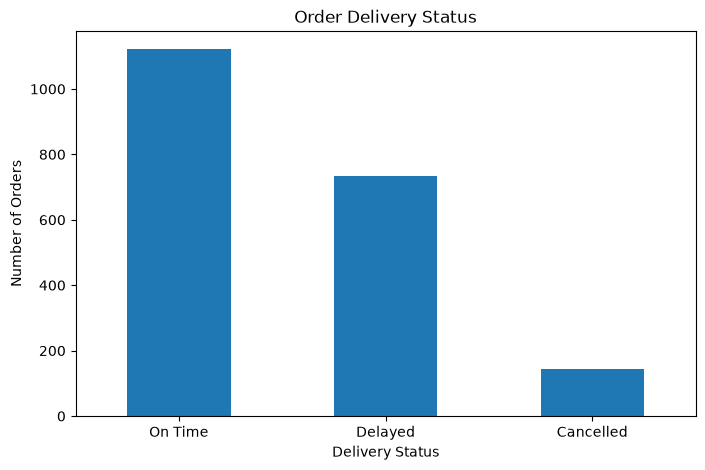

In [53]:
##Order Delivery Status

import matplotlib.pyplot as plt

status_counts = df["delivery_class"].value_counts()

plt.figure(figsize=(8, 5))

status_counts.plot(kind="bar")

plt.title("Order Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)

plt.show()



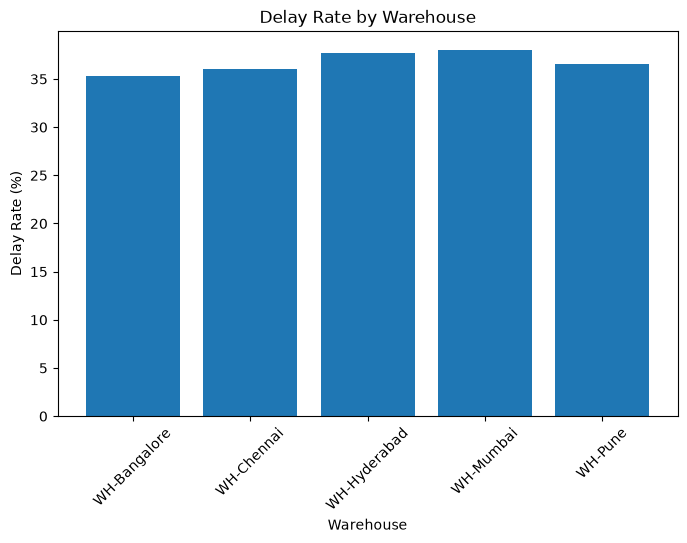

In [54]:
##Delay Rate by Warehouse

plt.figure(figsize=(8, 5))

plt.bar(
    warehouse_analysis["warehouse"],
    warehouse_analysis["delay_rate"]
)

plt.title("Delay Rate by Warehouse")
plt.xlabel("Warehouse")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=45)

plt.show()

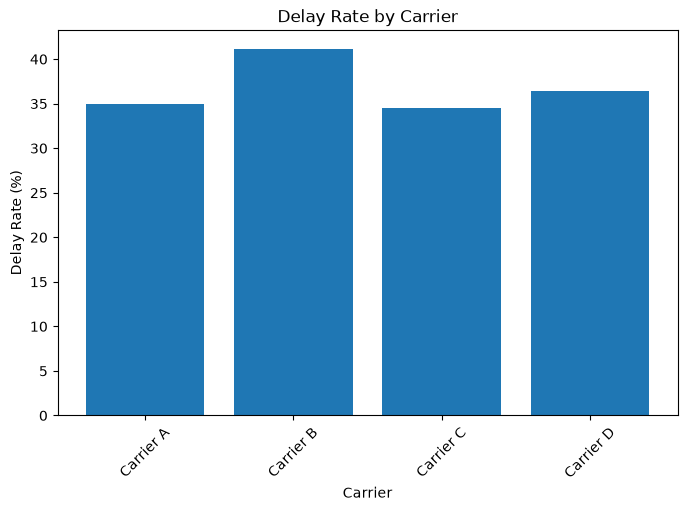

In [55]:
##Delay Rate by Carrier

plt.figure(figsize=(8, 5))

plt.bar(
    carrier_analysis["carrier"],
    carrier_analysis["delay_rate"]
)

plt.title("Delay Rate by Carrier")
plt.xlabel("Carrier")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=45)

plt.show()

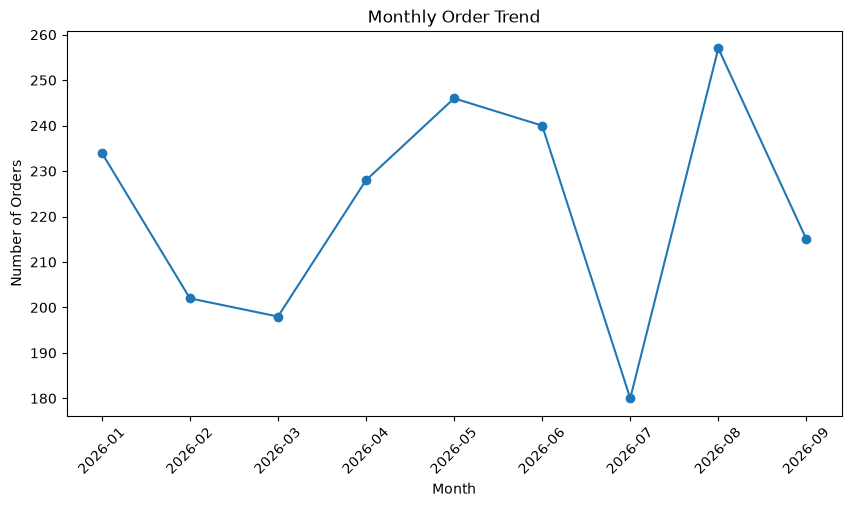

In [56]:
##Monthly Order Trend

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_analysis["month"],
    monthly_analysis["total_orders"],
    marker="o"
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()


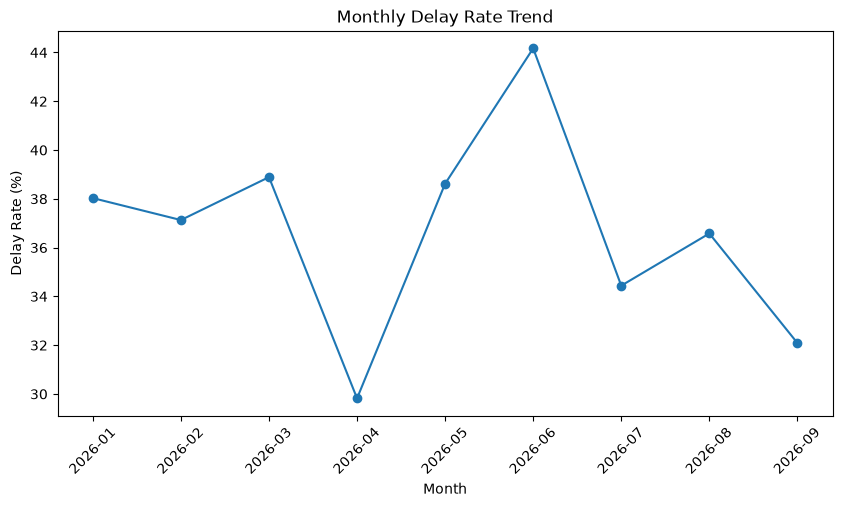

In [57]:
##Monthly Delay Rate

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_analysis["month"],
    monthly_analysis["delay_rate"],
    marker="o"
)

plt.title("Monthly Delay Rate Trend")
plt.xlabel("Month")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=45)

plt.show()

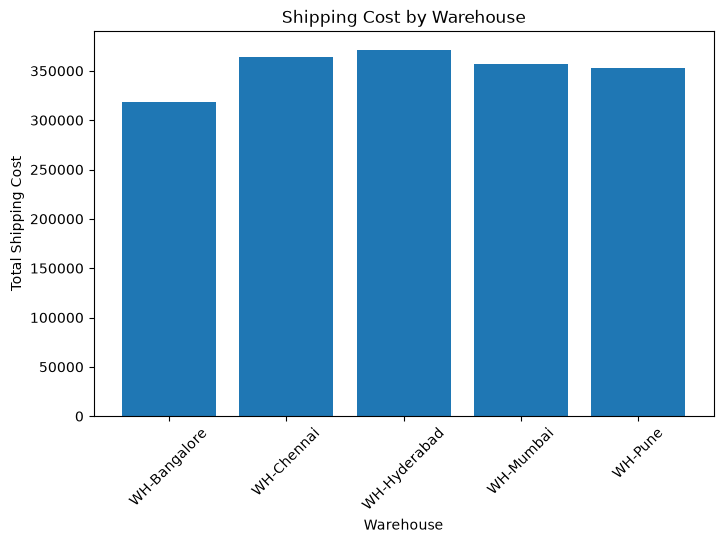

In [58]:
##Shipping Cost by Warehouse

plt.figure(figsize=(8, 5))

plt.bar(
    warehouse_analysis["warehouse"],
    warehouse_analysis["total_shipping_cost"]
)

plt.title("Shipping Cost by Warehouse")
plt.xlabel("Warehouse")
plt.ylabel("Total Shipping Cost")
plt.xticks(rotation=45)

plt.show()

In [59]:
##total delay and cancelled count 
exceptions = df[
    df["delivery_class"].isin(["Delayed", "Cancelled"])
]

print("Total exception orders:", len(exceptions))

Total exception orders: 879


In [60]:
## delay and cancelled count separately
print(exceptions["delivery_class"].value_counts())

delivery_class
Delayed      735
Cancelled    144
Name: count, dtype: int64


In [61]:
## exception order for 1st 10 rows 
exceptions[
    [
        "order_id",
        "warehouse",
        "region",
        "carrier",
        "shipping_cost",
        "delay_days",
        "status",
        "delivery_class"
    ]
].head(10)

,order_id,warehouse,region,carrier,shipping_cost,delay_days,status,delivery_class
2,O5003,WH-Hyderabad,South,Carrier A,268.70,NaN,Cancelled,Cancelled
3,O5004,WH-Chennai,South,Carrier C,580.68,1.0,Delivered,Delayed
4,O5005,WH-Mumbai,West,Carrier C,892.54,2.0,Delivered,Delayed
6,O5007,WH-Bangalore,South,Carrier A,1407.19,5.0,Delivered,Delayed
7,O5008,WH-Bangalore,South,Carrier B,1056.68,NaN,Cancelled,Cancelled
8,O5009,WH-Hyderabad,South,Carrier B,768.42,NaN,Cancelled,Cancelled
12,O5013,WH-Hyderabad,South,Carrier D,413.55,7.0,Delivered,Delayed
16,O5017,WH-Pune,West,Carrier C,1173.51,2.0,Delivered,Delayed
17,O5018,WH-Chennai,South,Carrier D,1031.51,NaN,Cancelled,Cancelled
21,O5022,WH-Bangalore,South,Carrier B,1285.34,NaN,Cancelled,Cancelled


In [62]:
##highest delay orders
exceptions[
    exceptions["delivery_class"] == "Delayed"
].sort_values(
    "delay_days",
    ascending=False
).head(10)

,order_id,order_date,warehouse,region,promised_date,delivered_date,carrier,shipping_cost,status,order_quantity,weight_kg,delay,delivery_days,delay_days,on_time_flag,delivery_class,month
1987,O6988,2026-04-28,WH-Chennai,South,2026-05-06,2026-05-13,Carrier D,931.95,Delivered,18,216.50,7,15.0,7.0,0,Delayed,2026-04
1978,O6979,2026-02-19,WH-Mumbai,West,2026-02-23,2026-03-02,Carrier C,262.79,Delivered,8,203.06,7,11.0,7.0,0,Delayed,2026-02
12,O5013,2026-05-11,WH-Hyderabad,South,2026-05-17,2026-05-24,Carrier D,413.55,Delivered,10,281.22,7,13.0,7.0,0,Delayed,2026-05
115,O5116,2026-01-13,WH-Bangalore,South,2026-01-17,2026-01-24,Carrier A,739.35,Delivered,4,800.42,7,11.0,7.0,0,Delayed,2026-01
311,O5312,2026-01-05,WH-Bangalore,South,2026-01-11,2026-01-18,Carrier B,1021.95,Delivered,3,509.42,7,13.0,7.0,0,Delayed,2026-01
1601,O6602,2026-05-24,WH-Bangalore,South,2026-05-31,2026-06-07,Carrier C,462.24,Delivered,3,410.66,7,14.0,7.0,0,Delayed,2026-05
1738,O6739,2026-05-22,WH-Bangalore,South,2026-05-30,2026-06-06,Carrier B,944.39,Delivered,12,281.33,7,15.0,7.0,0,Delayed,2026-05
1555,O6556,2026-06-08,WH-Bangalore,South,2026-06-16,2026-06-23,Carrier A,1439.50,Delivered,8,452.32,7,15.0,7.0,0,Delayed,2026-06
1013,O6014,2026-08-07,WH-Pune,West,2026-08-14,2026-08-21,Carrier C,1427.93,Delivered,20,48.46,7,14.0,7.0,0,Delayed,2026-08
1238,O6239,2026-01-31,WH-Bangalore,South,2026-02-08,2026-02-15,Carrier D,1288.91,Delivered,2,881.69,7,15.0,7.0,0,Delayed,2026-01


In [63]:
##Exception orders exported
exceptions.to_csv(
    "exception_orders.csv",
    index=False
)

print("Exception orders exported successfully.")

Exception orders exported successfully.


In [56]:
exception_export = exceptions[
    [
        "order_id",
        "order_date",
        "warehouse",
        "region",
        "carrier",
        "shipping_cost",
        "status",
        "delay_days",
        "delivery_class"
    ]
]

exception_export.to_csv(
    "exception_orders_clean.csv",
    index=False
)

print("Clean exception file exported successfully.")

Clean exception file exported successfully.


In [64]:
from IPython.display import FileLink, display

display(FileLink("exception_orders_clean.csv"))

C:\Users\user\exception_orders_clean.csv

In [65]:
### ML concept ####

In [66]:
ml_df = df[df["status"] == "Delivered"].copy()

ml_df["target"] = (
    ml_df["delivery_class"] == "Delayed"
).astype(int)

print(ml_df["target"].value_counts())

target
0    1121
1     735
Name: count, dtype: int64


In [67]:
## select future ##

features = [
    "warehouse",
    "region",
    "carrier",
    "shipping_cost",
    "order_quantity",
    "weight_kg"
]

X = ml_df[features]
y = ml_df["target"]

print(X.head())

      warehouse region    carrier  shipping_cost  order_quantity  weight_kg
0     WH-Mumbai   West  Carrier A         566.07              13     246.52
1       WH-Pune   West  Carrier C         896.75              17     891.21
3    WH-Chennai  South  Carrier C         580.68               4     193.08
4     WH-Mumbai   West  Carrier C         892.54              14     557.75
5  WH-Hyderabad  South  Carrier A         966.44              19     491.45


In [68]:
## encode the categorical column ##
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "warehouse",
    "region",
    "carrier"
]

numeric_features = [
    "shipping_cost",
    "order_quantity",
    "weight_kg"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

X_encoded = preprocessor.fit_transform(X)

print("Encoding completed.")
print("Encoded shape:", X_encoded.shape)

Encoding completed.
Encoded shape: (1856, 14)


In [69]:
## Train/Test Split ##

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1484, 14)
Testing data: (372, 14)


In [70]:
## Logistic Regression ##

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [75]:
## redictions ##

y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:20])
print("Prediction counts:")
print(pd.Series(y_pred).value_counts())

Predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Prediction counts:
0    369
1      3
Name: count, dtype: int64


In [76]:
## Accuracy & Classification Report ##

from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 60.75 %

Classification Report:
              precision    recall  f1-score   support

           0       0.61      1.00      0.75       225
           1       0.67      0.01      0.03       147

    accuracy                           0.61       372
   macro avg       0.64      0.50      0.39       372
weighted avg       0.63      0.61      0.47       372



Confusion Matrix:
[[224   1]
 [145   2]]


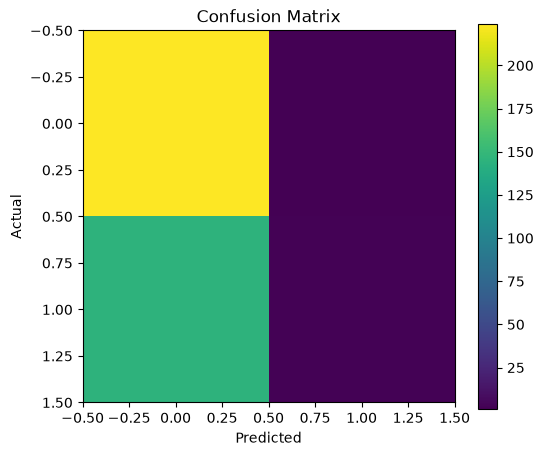

In [77]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [79]:
## decision tree model ##

In [80]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train, y_train)

print("Decision Tree training completed.")

Decision Tree training completed.


In [81]:
dt_pred = dt_model.predict(X_test)

print("Decision Tree Predictions:")
print(dt_pred[:20])

print("\nPrediction counts:")
print(pd.Series(dt_pred).value_counts())

Decision Tree Predictions:
[0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]

Prediction counts:
0    346
1     26
Name: count, dtype: int64


In [82]:
from sklearn.metrics import accuracy_score, classification_report

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", round(dt_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 56.72 %

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.91      0.72       225
           1       0.23      0.04      0.07       147

    accuracy                           0.57       372
   macro avg       0.41      0.48      0.39       372
weighted avg       0.45      0.57      0.46       372



In [83]:
## random forest model ##

In [84]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [85]:
rf_pred = rf_model.predict(X_test)

print("Random Forest Predictions:")
print(rf_pred[:20])

print("\nPrediction counts:")
print(pd.Series(rf_pred).value_counts())

Random Forest Predictions:
[0 1 0 0 0 0 0 0 1 1 0 1 1 1 0 1 0 1 1 0]

Prediction counts:
0    268
1    104
Name: count, dtype: int64


In [86]:
from sklearn.metrics import accuracy_score, classification_report

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 56.18 %

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.73      0.67       225
           1       0.42      0.30      0.35       147

    accuracy                           0.56       372
   macro avg       0.52      0.52      0.51       372
weighted avg       0.54      0.56      0.54       372



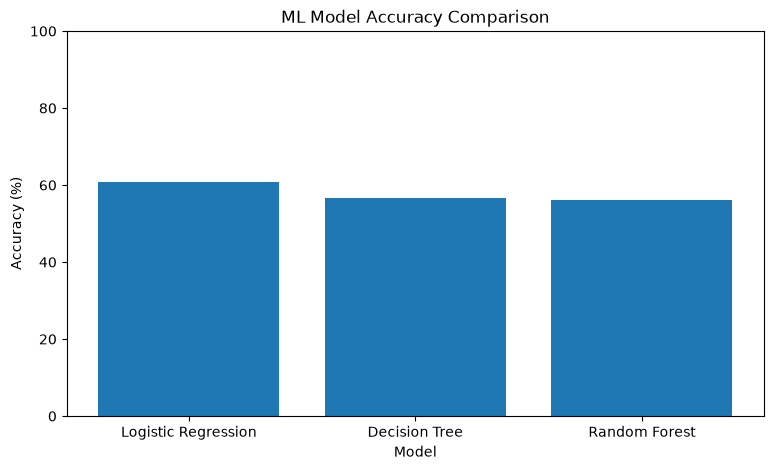

In [88]:
## model comparision chart ## 
models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]

accuracies = [
    60.75,
    56.72,
    56.18
]

plt.figure(figsize=(9, 5))
plt.bar(models, accuracies)

plt.title("ML Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

plt.show()

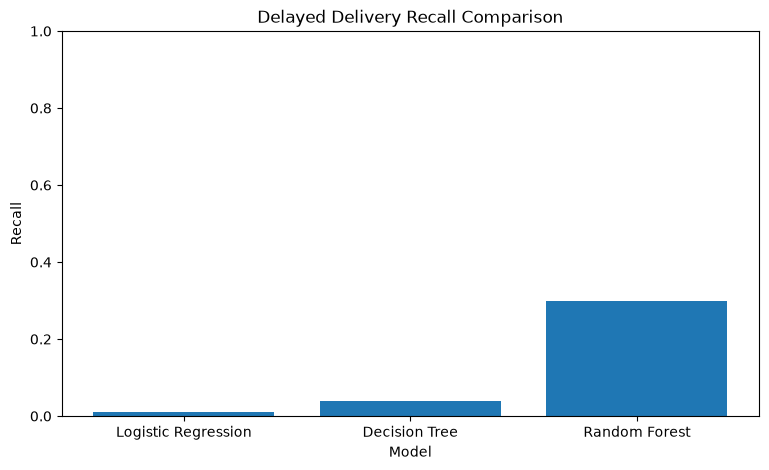

In [89]:
## Delayed Recall Comparison chart ##
delayed_recall = [
    0.01,
    0.04,
    0.30
]

plt.figure(figsize=(9, 5))
plt.bar(models, delayed_recall)

plt.title("Delayed Delivery Recall Comparison")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.ylim(0, 1)

plt.show()

In [90]:
## Final Recommendations & Project Conclusion ##

In [91]:
print("Highest Delay Warehouse:")
print(
    warehouse_analysis.loc[
        warehouse_analysis["delay_rate"].idxmax()
    ]
)

print("\nHighest Delay Carrier:")
print(
    carrier_analysis.loc[
        carrier_analysis["delay_rate"].idxmax()
    ]
)

print("\nHighest Delay Region:")
print(
    region_analysis.loc[
        region_analysis["delay_rate"].idxmax()
    ]
)

print("\nHighest Delay Month:")
print(
    monthly_analysis.loc[
        monthly_analysis["delay_rate"].idxmax()
    ]
)

Highest Delay Warehouse:
warehouse              WH-Mumbai
total_orders                 402
delayed_orders               153
on_time_orders               222
cancelled_orders              27
average_delay           0.989333
total_shipping_cost    356785.34
delay_rate                 38.06
on_time_percentage         55.22
Name: 3, dtype: object

Highest Delay Carrier:
carrier              Carrier B
total_orders               498
delivered_orders           460
cancelled_orders            38
delayed_orders             205
avg_shipping_cost       879.65
avg_delay_days             1.1
delay_rate               41.16
Name: 1, dtype: object

Highest Delay Region:
region                 West
total_orders            807
delivered_orders        756
cancelled_orders         51
delayed_orders          301
avg_shipping_cost    879.17
avg_delay_days         0.95
delay_rate             37.3
Name: 1, dtype: object

Highest Delay Month:
month                2026-06
total_orders             240
delivered_

# Final Recommendations

1. WH-Mumbai recorded the highest warehouse delay rate of 38.06%. Warehouse processing and dispatch operations should be reviewed.

2. Carrier B recorded the highest carrier delay rate of 41.16%. Carrier performance should be closely monitored.

3. The West region had the highest delay rate of 37.30%. Transportation and logistics operations should be reviewed.

4. June 2026 recorded the highest monthly delay rate of 44.17%. The reasons for this increase should be investigated.

5. Delayed and cancelled orders should be regularly monitored using exception reports.

6. Shipping costs should be compared with delivery performance to identify cost-effective transportation options.

7. Random Forest achieved a delayed-order recall of 30%. Further model improvement is required to improve delayed-order detection.

# Project Conclusion

This project analyzed supply chain and delivery performance using Python, Pandas, NumPy and visualization techniques. The analysis identified delivery delays across warehouses, carriers, regions and months. Exception orders were identified and exported for operational follow-up.

Machine learning models including Logistic Regression, Decision Tree and Random Forest were tested to predict delayed deliveries. Random Forest achieved a delayed-order recall of 30%, which was higher than the other tested models. Further model improvement can help improve delayed-order prediction and support better operational decision-making.